<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
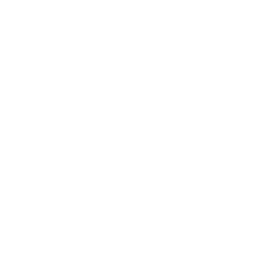
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bootstrap-luottamusvälit kliinisen tutkimuksen päätetapahtumille</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Lääketeollisuus / Kliininen biostatistiikka &nbsp;|&nbsp; Maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto

Tämä esimerkki laskee **ei-parametrisen bootstrap-luottamusvälin** eloonjäämispäätetapahtumalle käyttäen **PROC IML**:ää, SAS:n matriisiohjelmointikieltä. Päätetapahtuma on **etenemisvapaan elinajan (PFS) mediaanien suhde** pienen kaksihaaraisen onkologiakohortin hoito- ja verrokkihaaran välillä.

IML-ohjelma lukee koehenkilötason aineiston matriiseihin, laskee havaitun mediaani-PFS-suhteen, ottaa **2 000 bootstrap-uudelleenotosta** takaisinpanolla käyttäen `CALL RANDGEN`:ää, laskee suhteen uudelleen jokaisessa uudelleenotoksessa matriisioperaatioilla, ja johtaa **harhankorjatun ja kiihdytetyn (BCa)** luottamusvälin. BCa on tässä sopiva valinta, koska mediaanien suhteen bootstrap-jakauma on alhaalta rajattu nollaan, diskreetti ja vino — olosuhteet, joissa tavallinen normaaliteoriaan perustuva väli on epäluotettava.

Analyysi suoritetaan kokonaan IML:n sisällä: harhankorjausvakio *z*<sub>0</sub>, kiihdytys *a&#770;* jättäen-yksi-pois-jackknifesta, ja korjatut prosenttipiste-päätepisteet kootaan kaikki matriisilausekkeista ja standardinormaalijakauman funktioista `PROBNORM` sekä pienestä käänteisnormaalimoduulista. Jokainen alla raportoitu luku on luettu suoraan IML-tulosteesta.


## Tietolähteet

| Lähde | Kuvaus | Tietueet |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | Koehenkilökohtainen PFS-aika, tapahtumaosoitin, hoitohaara ja lähtötilanteen kovariaatit | 100 |

Kohortti on **tasapainotettu** — 50 koehenkilöä per haara — jakamalla haaran jäsenyys koehenkilötunnisteen parillisuuden mukaan, joten molemmat haarat ovat täysin edustettuina uudelleenotannassa.


---


In [1]:
/* --------------------------------------------------------
   Luodaan synteettinen kaksihaarainen onkologiakohortti.
   PFS-ajat ovat lognormaaleja; hoitohaara on siirretty
   pidempään mediaaniin. Haaran jäsenyys vaihtelee
   koehenkilötunnisteen mukaan, joten kohortti on tasapainotettu 50/50.
   -------------------------------------------------------- */
TIEDOT work.trial_subjects;
    CALL streaminit(42);
    PITUUS arm_label $10;
    TEE subject_id = 1 ASTI 500;
        /* 1 = Hoito, 0 = Verrokki (tasapainotettu parillisuuden mukaan) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'HOITO', 'VERROKKI');
        /* PFS-aika kuukausina: hoitohaaralla pidempi eloonjääminen */
        JOS arm = 1 NIIN
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        MUUTEN
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        JOS pfs_months < 0.5 NIIN pfs_months = 0.5;
        /* Tapahtumaosoitin: ~75 %:lla koehenkilöistä oli etenemistapahtuma */
        EVENT = (rand('uniform') > 0.25);
        /* Lähtötilanteen kovariaatit */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        JOS AGE < 25 NIIN AGE = 25;
        JOS AGE > 85 NIIN AGE = 85;
        TULOSTE;
    LOPPU;
SUORITA;



NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---


                                  Etenemisvapaan elinajan yhteenveto hoitohaaroittain                                   

                                                  The MEANS Procedure

                               Analysis Variable : pfs_months Etenemisvapaa elinaika (kk)

        Hoitohaara          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------------
        HOITO                  50          13.94          10.10          11.95           2.70          79.10
        VERROKKI               50          10.74           7.20           9.86           1.90          53.70
        ----------------------------------------------------------------------------------------------------

                                              Analysis Variable : AGE Ikä

        Hoitohaara          N Obs           Mean         Median        Std Dev        Minimum  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


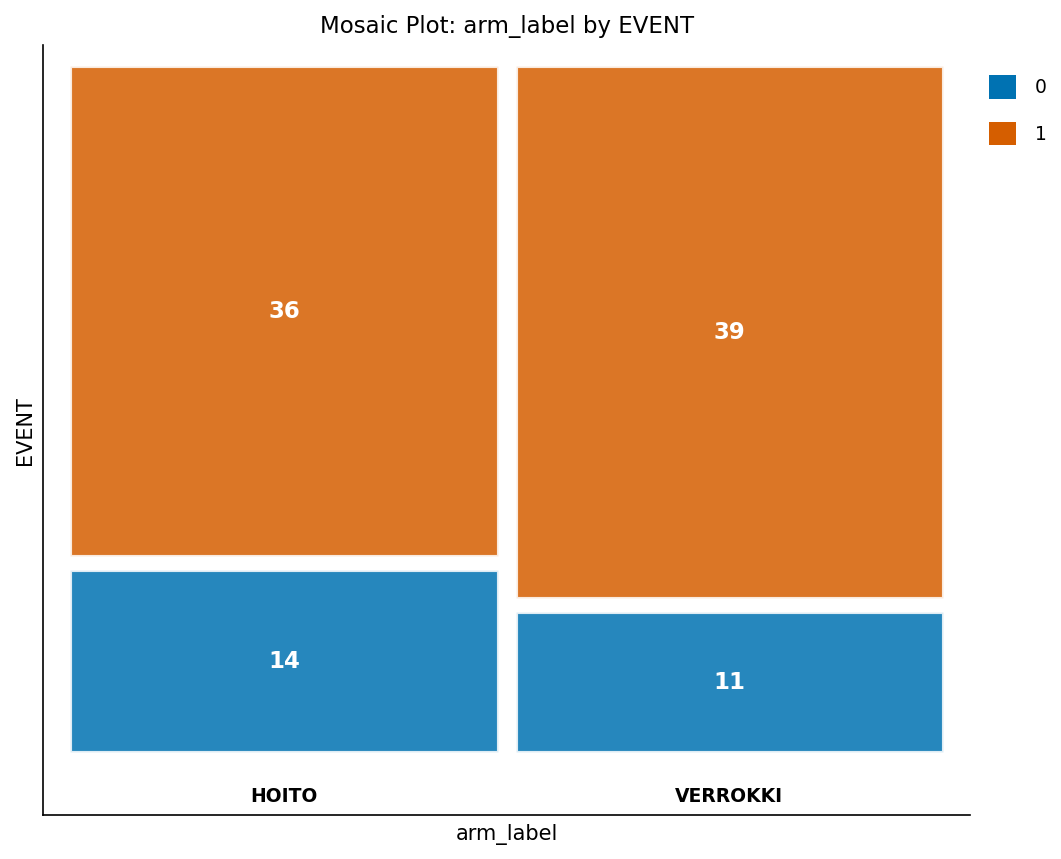

In [2]:
/* --------------------------------------------------------
   PFS-lähtötilanteen yhteenveto ja tapahtumaprosentti hoitohaaroittain
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    LUOKKA arm_label;
    MUUTTUJA pfs_months AGE;
    NIMIKE arm_label="Hoitohaara" pfs_months="Etenemisvapaa elinaika (kk)" AGE="Ikä";
    OTSIKKO "Etenemisvapaan elinajan yhteenveto hoitohaaroittain";
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    NIMIKE arm_label="Hoitohaara" EVENT="Tapahtuma";
    OTSIKKO "Tapahtumien lukumäärät hoitohaaroittain";
SUORITA;


---


In [3]:
/* --------------------------------------------------------
   PROC IML: ei-parametrinen bootstrap mediaani-PFS-suhteelle,
   BCa-luottamusvälillä.

   Vaiheet:
   1. Luetaan koehenkilöaineisto IML-matriiseihin
   2. Lasketaan havaittu mediaani-PFS-suhde (tapahtuma-ajat)
   3. Otetaan 2 000 bootstrap-uudelleenotosta CALL RANDGEN:llä
   4. Lasketaan suhde uudelleen jokaisessa uudelleenotoksessa
   5. BCa-korjaus: z0 (harha) + jackknife-kiihdytys
   6. Kirjoitetaan bootstrap-jakauma SAS-aineistoon
   -------------------------------------------------------- */
PROSEDUURI IML;

    /* --- Moduuli: mediaani-PFS haaraa kohden ja niiden suhde --- */
    /* Mediaani lasketaan vain havaituista tapahtuma-ajoista,
       tavanomainen ei-parametrinen yhteenveto, kun useimmat
       koehenkilöt etenevät. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        JOS nrow(trt_pfs) = 0 NIIN trt_med = .;
        MUUTEN trt_med = MEDIAN(trt_pfs);
        JOS nrow(ctl_pfs) = 0 NIIN ctl_med = .;
        MUUTEN ctl_med = MEDIAN(ctl_pfs);
        JOS ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            NIIN RATIO = trt_med / ctl_med;
        MUUTEN RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- Moduuli: käänteinen standardinormaalijakauman kertymäfunktio (probit) --- */
    /* Rationaalinen approksimaatio (Abramowitz & Stegun 26.2.23);
       yhdessä PROBNORM:n kanssa se tuottaa BCa-korjauksen tarvitsemat
       z0 / z-alpha-päätepisteet. */
    START probit(p);
        JOS p <= 0 NIIN RETURN(-1e8);
        JOS p >= 1 NIIN RETURN( 1e8);
        JOS p < 0.5 NIIN TEE; sgn = -1; pp = p;     LOPPU;
        MUUTEN            TEE; sgn =  1; pp = 1 - p; LOPPU;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Ladataan aineisto matriiseihin --- */
    USE work.trial_subjects;
        READ ALL MUUTTUJA {pfs_months} INTO pfs;
        READ ALL MUUTTUJA {arm}        INTO arm;
        READ ALL MUUTTUJA {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    TULOSTA 'Koehenkilöt luettu IML:ään', n n_trt n_ctl;

    /* --- 2. Havaittu tunnusluku koko otoksessa --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Hoito_Mediaani Verrokki_Mediaani Suhde};
    TULOSTA 'Havaittu mediaani-PFS (tapahtuma-ajat) hoitohaaroittain',
          obs[COLNAME=obs_lab MUOTO=8.3];

    /* --- 3. Bootstrap-uudelleenotannan silmukka (2 000 uudelleenotosta) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    CALL randseed(2024);
    TEE b = 1 ASTI n_boot;
        CALL randgen(u, 'Uniform');     /* uudet arvonnat joka kierroksella */
        idx = ceil(n # u);              /* indeksit 1..n takaisinpanolla */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    LOPPU;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    CALL SORT(bv, 1);

    /* --- 4. Tavallinen prosenttipisteväli (vertailua varten) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. BCa-korjaus --- */
    /* z0: harhankorjaus havaitun tunnusluvun alle jäävien
       uudelleenotosten osuudesta. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a-hat: kiihdytys jättäen-yksi-pois-jackknifesta. */
    jack = j(n, 1, .);
    TEE i = 1 ASTI n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    LOPPU;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Korjatut prosenttipistesijainnit. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {N_Kelvollinen Osuus_Alle z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    TULOSTA 'BCa-korjauksen diagnostiikka',
          diag[COLNAME=diag_lab MUOTO=8.4];

    ci_lab = {Havaittu_Suhde Pct_Ala Pct_Yla BCa_Ala BCa_Yla};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    TULOSTA '95% CI mediaani-PFS:n suhteelle (hoito / verrokki)',
          ci_row[COLNAME=ci_lab MUOTO=8.4];

    /* --- 6. Tallennetaan bootstrap-jakauma --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREATE work.bootstrap_results
        MUUTTUJA {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND MUUTTUJA {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;


                                        Tapahtumien lukumäärät hoitohaaroittain                                         

Koehenkilöt luettu IML:ään
     100
      50
      50

Havaittu mediaani-PFS (tapahtuma-ajat) hoitohaaroittain
   9.900   7.100   1.394

BCa-korjauksen diagnostiikka
2000.0000  0.5340  0.0851 -0.0021

95% CI mediaani-PFS:n suhteelle (hoito / verrokki)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  1.96 seconds
  cpu   1.96 seconds


---


In [4]:
/* --------------------------------------------------------
   Siistitään bootstrap-jakauma kuvaamista varten: annetaan
   sarakkeille kuvaavat nimet alla olevaa histogrammia varten.
   -------------------------------------------------------- */
TIEDOT work.bootstrap_results;
    ASETA work.bootstrap_results;
    NIMEÄ_UUDELLEEN boot=RATIO
           obs_col=obs_ratio
           bca_lo_col=bca_lower
           bca_hi_col=bca_upper;
SUORITA;



NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---


                                        Tapahtumien lukumäärät hoitohaaroittain                                         




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


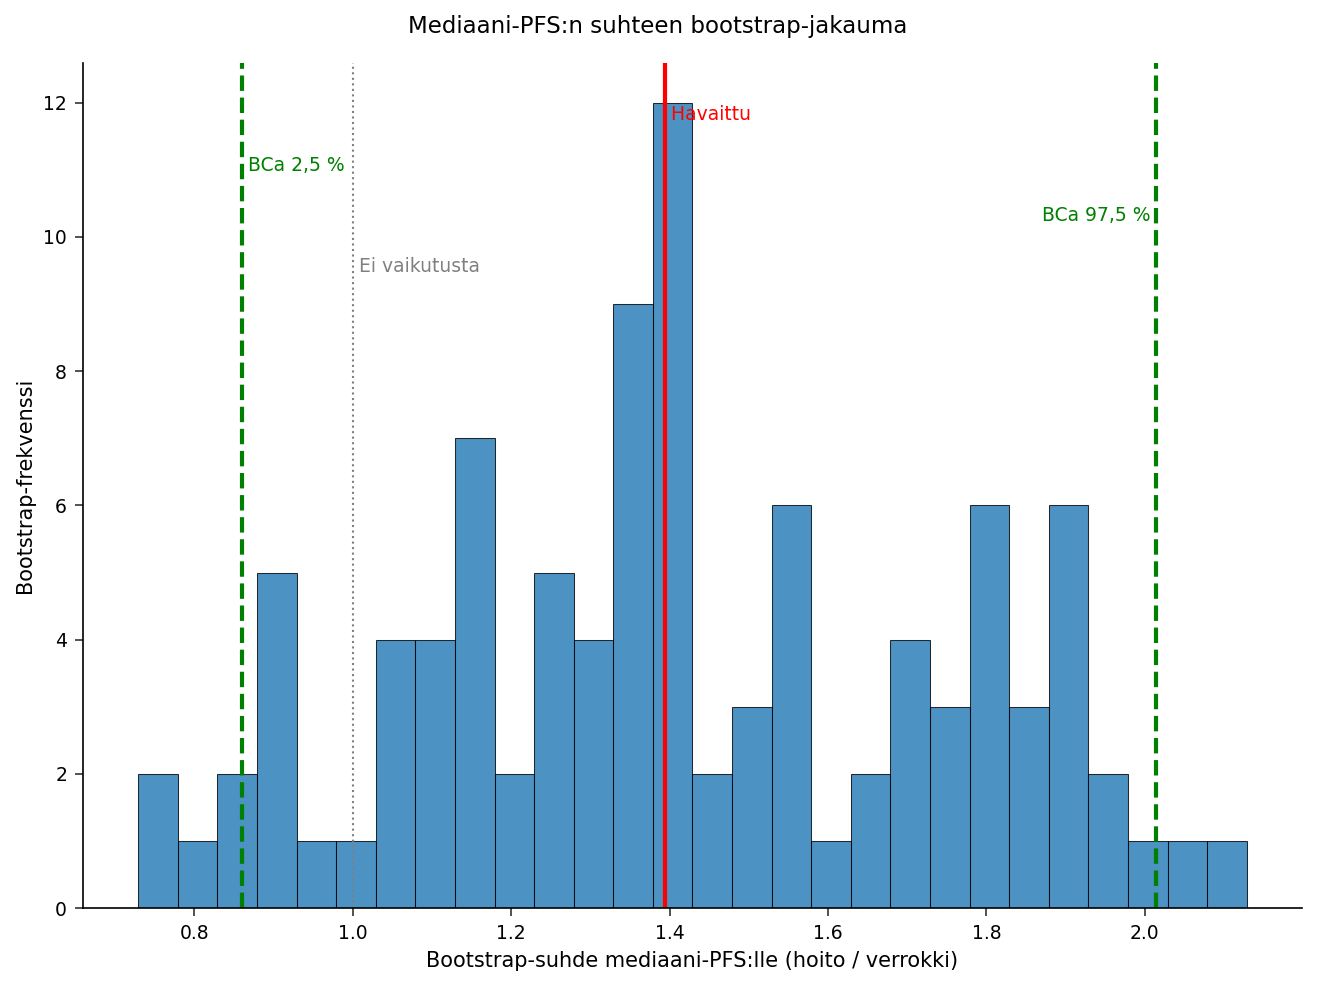

In [5]:
/* --------------------------------------------------------
   Mediaani-PFS-suhteen bootstrap-jakauma, havaitulla
   estimaatilla ja BCa-välillä merkittynä.
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) NIMIKE="Havaittu";
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        NIMIKE="BCa 2,5 %";
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        NIMIKE="BCa 97,5 %";
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        NIMIKE="Ei vaikutusta";
    XAXIS NIMIKE="Bootstrap-suhde mediaani-PFS:lle (hoito / verrokki)";
    YAXIS NIMIKE="Bootstrap-frekvenssi";
    OTSIKKO "Mediaani-PFS:n suhteen bootstrap-jakauma";
SUORITA;


---


### Tulkinta

Tässä kohortissa havaittu mediaani-PFS tapahtuma-aikojen yli on **9,9 kuukautta** hoitohaarassa ja **7,1 kuukautta** verrokkihaarassa, eli **suhde 1,394** — kokeellisen haaran mediaani-PFS on noin 39 % pidempi. IML-ohjelma otti 100 koehenkilöstä 2 000 uudelleenotosta; kaikki 2 000 uudelleenotosta tuottivat määritellyn suhteen.

**BCa 95 %:n luottamusväli suhteelle on [0,86, 2,01]**, kun tavallinen prosenttipisteväli on **[0,82, 1,97]**. Molemmat välit **sisältävät arvon 1,0**, joten tässä otoskoossa — noin 50 koehenkilöä per haara, ohennettuna edelleen havaittuihin tapahtuma-aikoihin — näennäinen hyöty **ei ole tilastollisesti ratkaiseva**. Tämä on analyysin rehellinen viesti: piste-estimaatti suosii hoitoa, mutta uudelleenotannan epävarmuus on riittävä, jotta ei voida sulkea pois sitä, ettei hoitovaikutusta ole.

BCa-diagnostiikka kvantifioi, kuinka paljon korjaus siirsi päätepisteitä. Harhatermi on pieni (**z<sub>0</sub> = 0,085**: noin 53 % uudelleenotoksista jäi havaitun suhteen alle, lähellä symmetristä 50 %:a), ja kiihdytys on lähellä nollaa (**a&#770; = -0,002**), mikä osoittaa, että mediaani-PFS-suhde on vain lievästi yksittäisten koehenkilöiden vaikutuksen alainen. Kun sekä z<sub>0</sub> että a&#770; ovat pieniä, BCa siirtää väliä vain hieman ylöspäin suhteessa prosenttipisteväliin — juuri se maltillinen korjaus, jonka nämä diagnostiikka-arvot ennustavat.

Suurempi tutkimus kaventaisi tätä väliä. 50 koehenkilöllä per haara bootstrap raportoi oikein, että aineisto on yhteensopiva kaiken kanssa pienestä käänteisestä vaikutuksesta mediaani-PFS:n kaksinkertaistumiseen, minkä vuoksi tämän kokoisen PFS-eron havaitsemiseen voimistettu tutkimus tarvitsee huomattavasti enemmän kuin 100 koehenkilöä.


---


In [6]:
/* --------------------------------------------------------
   Viedään bootstrap-jakauma raportin liitteeksi.
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
SUORITA;



NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Käyttövoimana: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>